### 工作進度  
* 新的筆記架構仍待定。構想如下：  
  - 第一部分：盤前解盤？  
      - 參照老師的「[盤前快訊](https://www.facebook.com/kevinyang20180801/posts/pfbid0eHdLcPCzdE2HAcbKD8evNX4BhvyMPQvUkFkt7xEguht8ey3G2JdHtQg55VktSsp3l)」（如果有）。  
      - 資訊分析：夜盤期指、美股指數。
  - 第二部分：大盤解盤  
    * 『加權指數』與『櫃買指數』。  
      - 執行mysys.StockAnalysis類別的analysis方法  
        * 針對量化與ＡＩ分析結果加入個人觀點。  
        * 補充老師盤中資訊，來源於[日報](https://mega.nz/folder/a85wHKwK#SA6HACStdXRvMsLd2Ct0tQ)。  
    * 老師手繪的趨勢線進行量化（[主觀性質的客觀化](https://ithelp.ithome.com.tw/articles/10314112)，參考書籍：[讓證據說話的技術分析(上)](https://www.books.com.tw/products/0010410837)），使用mysys.DrawOnKlineChart函式。  
  - 第三部分：個股解盤  
    * **選股**來源  
      - 老師觀察股  
        * [K線追擊週報](https://smart.businessweekly.com.tw/e-subscription/project?c=GROUP00014146&p=PROD000019311)LINE群組  - 參閱[日報](https://mega.nz/folder/a85wHKwK#SA6HACStdXRvMsLd2Ct0tQ)  
      - 自選觀察股  
        * [股票篩選器：中價位且平均趨向指標(ADX)上升穿越20](https://tw.tradingview.com/screener/FFH7FtPz/)  
    * 個股解盤  
      - 執行mysys.StockAnalysis類別的analysis方法。
      - 老師手繪的趨勢線進行量化（[主觀性質的客觀化](https://ithelp.ithome.com.tw/articles/10314112)，參考書籍：[讓證據說話的技術分析(上)](https://www.books.com.tw/products/0010410837)），使用mysys.DrawOnKlineChart函式。  
      - 補充籌碼面資訊：因為不是所有市場都有籌碼面資訊，因此很難透過AI進行分析，只能人工進行確認。
* 預計8月1日開始使用新的筆記架構，並重啟新的GitHub倉庫來做發佈。  

#### 引入模組與定義公用函式  
* 這部分在筆記架構中該如何定位？  

In [1]:
import numpy as np
import mysys
import markdown
import base64
from IPython.core.display import HTML

In [2]:
def stock_analysis( analysis, stock_id, buttom_pattern = False) :
    results,images = analysis.analysis(stock_id)
    if buttom_pattern is True and '底部型態' in images :
        print('底型反轉交易策略：')
        display(images['底部型態'])
    print('解盤內容：')
    if '整體評價' in images :
        display(images['整體評價'])
    result_md   = results.to_markdown(tablefmt="grid")
    result_html = markdown.markdown(result_md, extensions=['markdown_grid_tables:GridTableExtension'])
    display(HTML(result_html))

#### 建立「解盤」物件    

In [3]:
analysis = mysys.StockAnalysis()

### 盤前解析  

📢【K線捕手｜7/14盤前快訊】上升楔形 × 觀望氛圍 × 避險思維升溫  
  
🌍 市場焦點：美中關稅未解，資金轉趨保守觀望  
  
📉 技術面亮點：  
1️⃣ 上升楔形形成、區間狹幅震盪，多數指標失靈  
2️⃣ 短中長期均線糾結，方向不明  
3️⃣ 成交量持續萎縮，等待突破契機  
4️⃣ 籌碼分歧：外資偏多、內資偏空，融資觀望為主  
5️⃣ 多空比例：多方約佔 2 成、空方約佔 4 成  
  
🔍 總結：上周五夜盤表現偏弱，早盤開低機率較高，中期盤勢多空未明，操作宜降低預期、拉高防守操作轉趨保守  
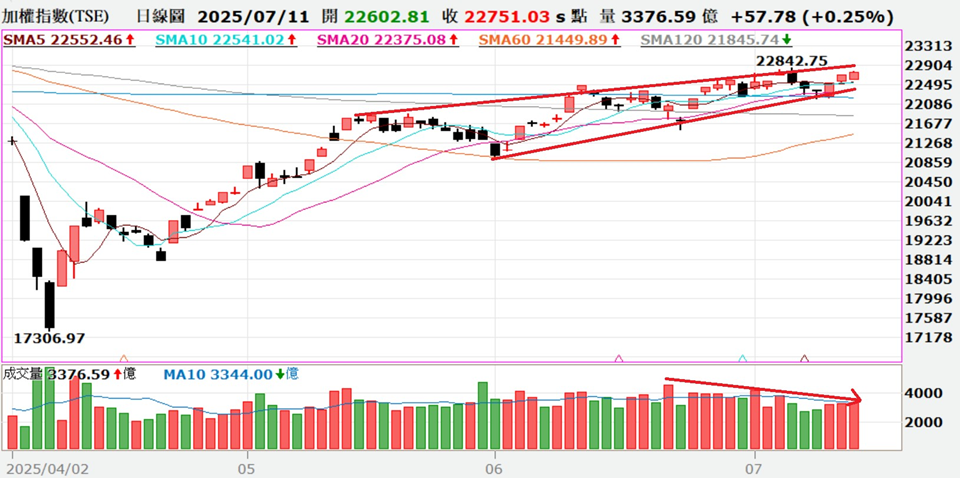

In [4]:
def line_drawing_callback( range_prices) :
    # 設定楔形壓力線
    resistance_line_start_date  = '2025-05-14'
    resistance_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    resistance_line_x           = [mysys.DateToIndex(range_prices,'2025-05-16'),mysys.DateToIndex(range_prices,'2025-07-04')]
    resistance_line_y           = [range_prices.loc['2025-05-16']['Close'],range_prices.loc['2025-07-04']['Open']]
    slope,intercept             = np.polyfit(resistance_line_x,resistance_line_y,1)
    resistance_line_start_price = slope * mysys.DateToIndex(range_prices,resistance_line_start_date) + intercept
    resistance_line_end_price   = slope * mysys.DateToIndex(range_prices,resistance_line_end_date) + intercept

    # 設定楔形支撐線
    support_line_start_date  = '2025-06-02'
    support_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    support_line_x           = [mysys.DateToIndex(range_prices,'2025-06-02'),mysys.DateToIndex(range_prices,'2025-07-09')]
    support_line_y           = [range_prices.loc['2025-06-02']['Low'],(range_prices.loc['2025-07-08']['Close'] + range_prices.loc['2025-07-09']['Open'])/2]
    slope,intercept          = np.polyfit(support_line_x,support_line_y,1)
    support_line_start_price = slope * mysys.DateToIndex(range_prices,support_line_start_date) + intercept
    support_line_end_price   = slope * mysys.DateToIndex(range_prices,support_line_end_date) + intercept

    seq_of_seq_of_points=[
        [(resistance_line_start_date,resistance_line_start_price),(resistance_line_end_date,resistance_line_end_price)],
        [(support_line_start_date,support_line_start_price),(support_line_end_date,support_line_end_price)]
    ]

    linewidths=[1.5,1.5]
    
    colors=['xkcd:red','xkcd:red']

    return seq_of_seq_of_points,linewidths,colors

In [5]:
image = mysys.DrawOnKlineChart('TAIEX','2025-04-02','2025-07-11',line_drawing_callback)

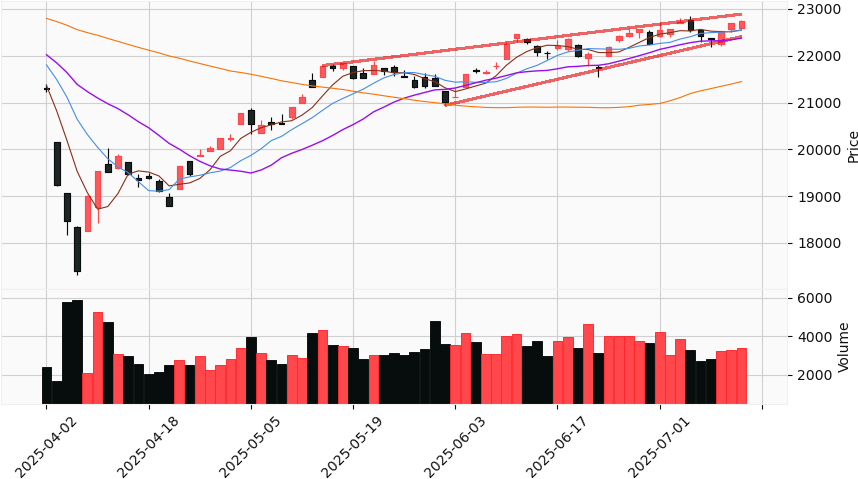

In [6]:
display(image)

### 大盤解盤  

* 加權指數

解盤內容：


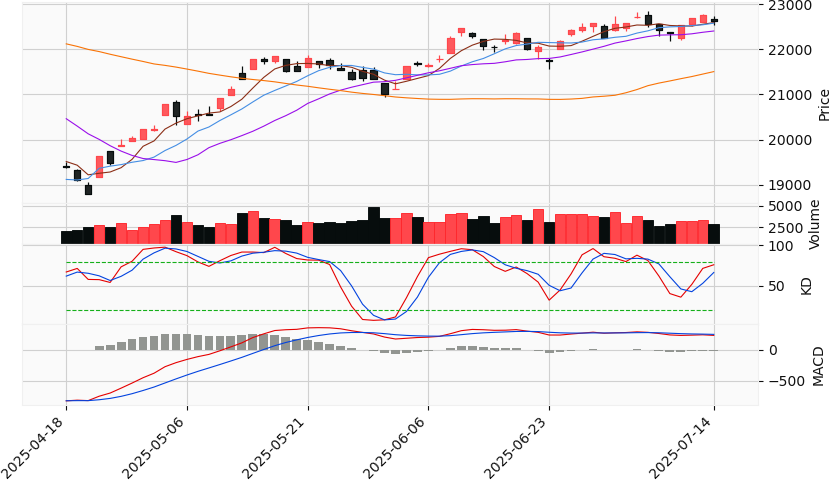

技術分析工具,解盤內容
Ｋ線／Ｋ棒,十字線 : 2025-07-08 吞噬 : 2025-07-09 孕育線／懷抱線 : 2025-07-14
Ｋ線圖,中期為高位階 長期為中位階
成交量,價量關係：未至大量門檻（成交量 ＝ 2815.13億元 ，十日均量 ＝ 3262.58億元）
型態,反轉型態之三重頂，型態範圍由2024-08-12開始到2025-03-03結束，估算目標價為21371.25。 底型反轉之底部型態，型態範圍由2025-04-02開始到2025-05-02結束，估算目標價為22257.56。
移動平均線,5日線上揚、10日線上揚，短期翻多；20日線上揚、60日線上揚，中期翻多；120日線下彎、240日線下彎，長期翻空
ＫＤ指標,於2025-07-10黃金交叉。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-06-23當周黃金交叉。並且2025-07-07該周在超買區。
整體評價,根據圖表進行技術分析如下： 價格趨勢 近期價格呈現上漲趨勢，K線多數為紅K，顯示多頭力量較強。短期移動平均線（5日、10日）均在中期移動平均線（20日、60日）之上，且呈現多頭排列，顯示上漲趨勢明顯。 價量關係 成交量在上漲時有所增加，顯示價量配合良好，支持上漲趨勢。這表明市場對於目前的價格上漲有較強的信心。 支撐與壓力 支撐位置可參考20日移動平均線，約在22000點附近。壓力位置則在近期高點23000點左右，若能有效突破，將有機會進一步上漲。 KD指標解讀 KD指標顯示K線（紅線）高於D線（藍線），且接近超買區，但尚未進入超買區，顯示短期內仍有上漲空間，但需注意可能的回檔風險。 MACD指標解讀 MACD指標中，DIF線（紅線）高於MACD線（藍線），且灰色柱體為正值，顯示多頭趨勢持續，市場情緒偏多。 綜合評價 整體來看，市場目前處於上漲趨勢，價量配合良好，短期內有望繼續上漲。然而，由於KD指標接近超買區，需留意可能的回檔風險。建議投資者可考慮在支撐位附近進行佈局，並設置適當的停損點以控制風險。


In [7]:
stock_analysis(analysis,'TAIEX')

In [8]:
image = mysys.DrawOnKlineChart('TAIEX','2025-04-02','2025-07-14',line_drawing_callback)

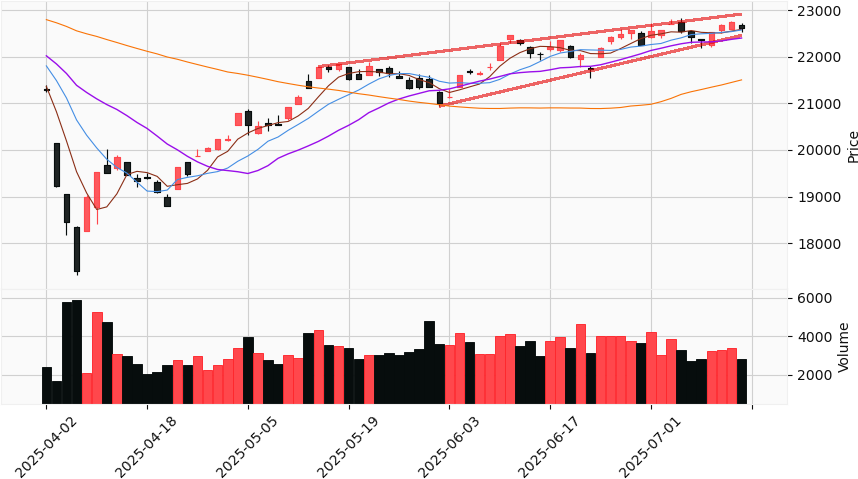

In [9]:
display(image)

* 櫃買指數

解盤內容：


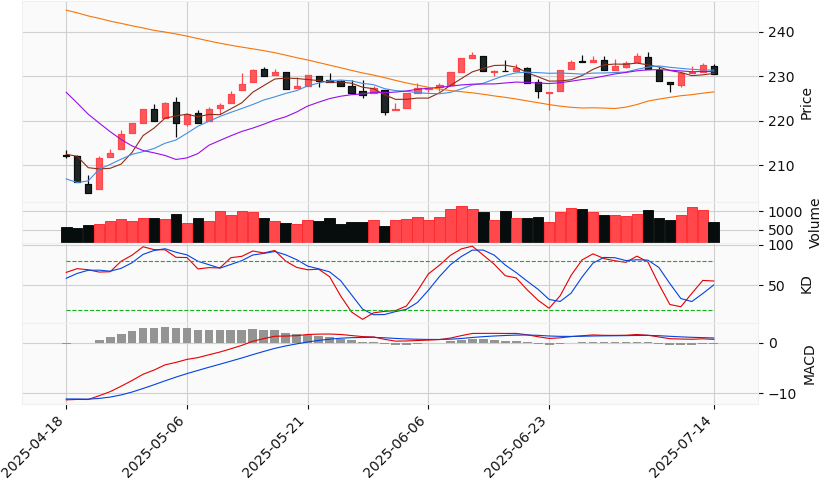

技術分析工具,解盤內容
Ｋ線／Ｋ棒,鎚子線／吊人線 : 2025-07-08 吞噬 : 2025-07-09
Ｋ線圖,中期為中位階 長期為低位階
成交量,價量關係：未至大量門檻（成交量 ＝ 726.39億元 ，十日均量 ＝ 912.72億元）
型態,盤整型態之三角形，型態範圍由2024-07-11開始到2025-03-28結束。 底型反轉之底部型態，型態範圍由2025-04-02開始到2025-05-02結束，估算目標價為247.79。
移動平均線,5日線上揚、10日線下彎，短期盤整；20日線下彎、60日線上揚，中期盤整；120日線下彎、240日線下彎，長期翻空
ＫＤ指標,於2025-07-10黃金交叉。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-06-02當周死亡交叉。
整體評價,技術分析 價格趨勢 目前價格處於盤整階段。K線圖顯示價格在230至240點之間波動，沒有明顯的上升或下降趨勢。短期移動平均線（5日和10日）與中期移動平均線（20日和60日）交錯，顯示出市場缺乏明確方向。 價量關係 成交量在最近幾個交易日中保持穩定，沒有明顯的放量或縮量現象。這表明市場參與者對當前價格區間的認同，缺乏強烈的買入或賣出動機。 支撐與壓力 支撐位大約在230點，壓力位在240點。價格多次在這兩個點位之間反彈或回檔，顯示出這些位置的有效性。 KD指標解讀 KD指標顯示K線和D線在50附近交錯，並未進入超買或超賣區域。這表明市場情緒中性，短期內可能繼續盤整。 MACD指標解讀 MACD指標顯示DIF線和MACD線接近零軸，且柱狀體顯示出微弱的正值，表明市場動能不足，短期內可能維持盤整。 綜合評價 整體來看，市場目前處於盤整狀態，缺乏明確的上升或下降動能。建議投資者在此階段保持觀望，等待價格突破支撐或壓力位後再行動。若價格突破240點，可能會迎來新的上升趨勢；若跌破230點，則需警惕下行風險。


In [10]:
stock_analysis(analysis,'TPEx')